Org data dimension is 6.Embedded data dimension is 2


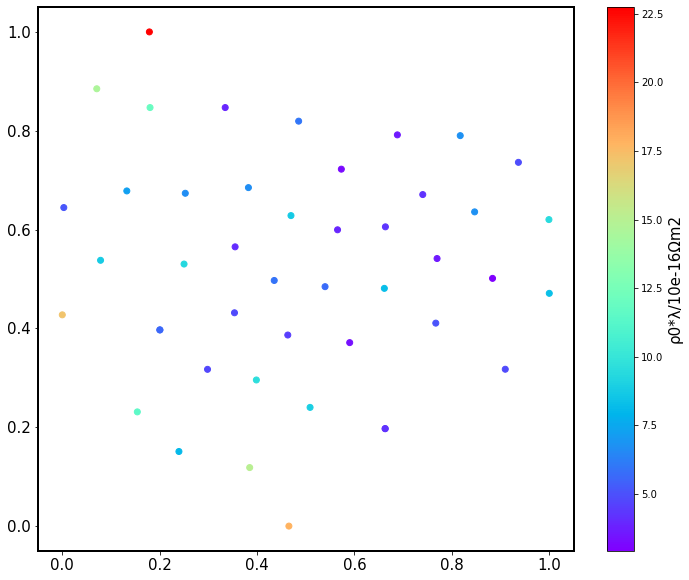

In [1]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
import numpy as np
from modules import *
import seaborn as sns
#电阻部分
File = '../newdata/002'
X,y=sub_data(File)
X,y= pre_data(X,y)
X=np.delete(X,[29],axis=0)
y=np.delete(y,[29],axis=0)
X=np.delete(X,[3,7,8,9,10],axis=1)
#内聚能部分
# File = '../newdata/data001-cohesive'
# X,y=sub_data(File)
# X,y= pre_data(X,y)

'''t-SNE'''
tsne = manifold.TSNE(n_components=2,init='pca', random_state=501)
X_tsne = tsne.fit_transform(X)
print("Org data dimension is {}.Embedded data dimension is {}".format(X.shape[-1], X_tsne.shape[-1]))
 
'''visualization'''
x_min, x_max = X_tsne.min(0), X_tsne.max(0)
X_norm = (X_tsne - x_min) / (x_max - x_min)  # 归一化
#print(X_norm[-6:,:])
#plt.figure()
# # 三维图表
# fig = plt.figure()
# fig = plt.figure(figsize=(12, 10))
# ax = fig.add_subplot(111, projection='3d')

# path = ax.scatter(X_norm[:, 0], X_norm[:, 1], X_norm[:,2],s=30, c=y, cmap=plt.cm.rainbow)
# # 如果需要，可以添加颜色条
# #cbar = fig.colorbar(path, ax=ax, pad=0.1)
# cbar = fig.colorbar(ax.collections[0], pad=0.1, cmap=plt.cm.rainbow, shrink=0.6)
# ax.set_xlabel('Feature 1',fontsize=20)
# ax.set_ylabel('Feature 2',fontsize=20)
# ax.set_zlabel('Feature 3',fontsize=20)

# # 显示图表
# plt.show()
plt.figure(figsize=(12,10))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
#path=plt.plot(X_norm[:, 0], X_norm[:, 1],'bo')
#path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y,cmap=plt.cm.gist_rainbow,alpha=0.5,)
#path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y,cmap=plt.cm.Paired,alpha=0.5)
#path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y, cmap=plt.cm.Spectral)
path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y, cmap=plt.cm.rainbow)
#path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c='r')

cb=plt.colorbar(drawedges=False, orientation='vertical',spacing='uniform')
cb.set_label('ρ0*λ/10e-16Ωm2', fontsize=15)
#cb.ax.tick_params(length=2)
#cb.ax.tick_params(size=1,width=1,color='b')
#cb.ax.tick_params(size=5,width=1,labelsize=12)
plt.savefig('0-feat_dist.png',dpi=300,bbox_inches='tight')
plt.show()

# 整体的点的分布，分预测和实际

Org data dimension is 6.Embedded data dimension is 2


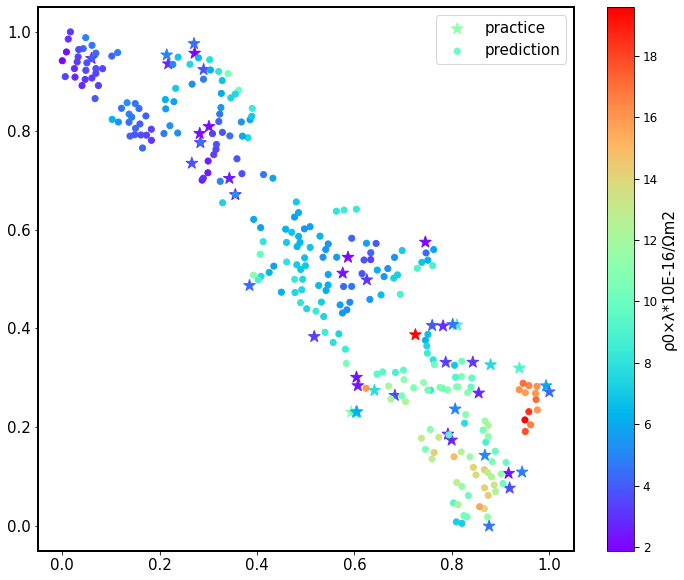

In [43]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn import manifold
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from modules import *
import seaborn as sns

File = '../newdata/NT-EL'

X,y=sub_data(File)
scaler=StandardScaler()
scaler.fit(X)
X=scaler.transform(X)
#X=np.delete(X,[0,1,4,5],axis=1)
# 电阻部分去除异常数据
# X=np.delete(X,[29],axis=0)
# y=np.delete(y,[29],axis=0)
# # #用于除去实验数据
# X=np.delete(X,list(range(43)),axis=0)
# y=np.delete(y,list(range(43)),axis=0)


'''t-SNE'''
tsne = manifold.TSNE(n_components=2,init='pca', random_state=501)
X_tsne = tsne.fit_transform(X)
print("Org data dimension is {}.Embedded data dimension is {}".format(X.shape[-1], X_tsne.shape[-1]))
 
'''visualization'''

x_min, x_max = X_tsne.min(0), X_tsne.max(0)
X_norm = (X_tsne - x_min) / (x_max - x_min)  # 归一化
# X_norm=np.delete(X_norm,list(range(43)),axis=0)
# y=np.delete(y,list(range(43)),axis=0)
#y=np.delete(y,[0,1,2],axis=1)
#print(X_norm[-6:,:])
#plt.figure()

plt.figure(figsize=(12,10))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
is_first_43_rows = np.arange(X_norm.shape[0]) < 45
# 内聚能部分
#is_first_43_rows = np.arange(X_norm.shape[0]) < 40

# 为前43行和剩余行分别绘制散点图
plt.scatter(X_norm[is_first_43_rows, 0], X_norm[is_first_43_rows, 1], 
            c=y[is_first_43_rows], cmap=plt.cm.rainbow, 
            marker='*',s=150, alpha=1, label='practice')  # 使用三角形标记

plt.scatter(X_norm[~is_first_43_rows, 0], X_norm[~is_first_43_rows, 1], 
            c=y[~is_first_43_rows], cmap=plt.cm.rainbow, s=150,alpha=1, 
            marker ='.',label='prediction')  # 使用圆形标记

#path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y, cmap=plt.cm.rainbow)
# 添加图例
plt.legend(fontsize=15)
cb=plt.colorbar(drawedges=False, orientation='vertical',spacing='uniform')
#cb.set_label('cohesive/ev', fontsize=15)
cb.set_label('ρ0×λ*10E-16/Ωm2', fontsize=15)
#cb.ax.tick_params(length=2)
#cb.ax.tick_params(size=1,width=1,color='b')
cb.ax.tick_params(size=5,width=1,labelsize=12)

plt.savefig('NO-EL.png',dpi=300,bbox_inches='tight')
plt.show()

# 联合密度分布

In [51]:
def plot_train_test_results_1(y_train,y_test,y_pre1,y_pre2,output=True,fname='EC',plt_prop=True,patt='Set1'):
   train_typ,test_typ=[],[]
   for i in range(38):
     train_typ+=['Train']
   for i in range(266):
     test_typ+=['Test']
   data0=np.transpose(np.vstack((y_train,y_pre1)))
   d0=pd.DataFrame(data0,columns=['Calculated Values(ev)','Predicted Values(eev)'])

   data1=np.transpose(np.vstack((train_typ,y_train,y_pre1)))
   d1=pd.DataFrame(data1,columns=['Type','Calculated Values(ev)','Predicted Values(ev)'])

   data2=np.transpose(np.vstack((test_typ,y_test,y_pre2)))
   d2=pd.DataFrame(data2,columns=['Type','Calculated Values(ev)','Predicted Values(ev)'])

   data=np.vstack((data1,data2))
   d3=pd.DataFrame(data,columns=['Type','Calculated Values(ev)','Predicted Values(ev)'])
   d3["Calculated Values(ev)"]=pd.to_numeric(d3["Calculated Values(ev)"])
   d3["Predicted Values(ev)"]=pd.to_numeric(d3["Predicted Values(ev)"])
    
   lim0=min(min(y_train),min(y_pre1),min(y_test),min(y_pre2))
   lim1=max(max(y_train),max(y_pre1),max(y_test),max(y_pre2))
   sns.set_context("talk",font_scale=1.5,rc={'font.size': 25.0,
 'legend.fontsize':20,
 'legend.title_fontsize':20,
 'axes.linewidth':2.0,
 'axes.labelsize': 20.0,
 'axes.titlesize': 20.0,
 'xtick.labelsize': 16.5,
 'ytick.labelsize': 16.5,})

   g=sns.JointGrid(x='Calculated Values(ev)', y='Predicted Values(ev)', hue='Type',data=d3,space=0.0,height=10,ratio=10,xlim=(lim0,lim1), ylim=(lim0,lim1))
   # 设置轴名称为空
   g.set_axis_labels("", "")
   #g=sns.JointGrid(x='Calculated Values(eV)', y='Predicted Values(eV)', hue='Type',data=d3,space=0.0,height=10,ratio=10,xlim=(-7.5,1), ylim=(-7.5,1))
   g.plot_joint(sns.scatterplot,s=75, palette=patt,legend='auto')
   g.plot_marginals(sns.kdeplot,fill=True,palette=patt,common_norm=False)
   
   '''
   g=sns.JointGrid(x='Calculated Values(eV)', y='Predicted Values(eV)', data=d3)
   g=g.plot_joint(plt.scatter,color='g',s=40,edgecolor='white')
   plt.grid(linestyle='--')
   #g.plot_marginals(sns.distplot,kde=True,color='g')
   g.plot_marginals(sns.kdeplot,shade=True,color='g')
   '''
   if output:
      plt.savefig(f'{fname}.png',dpi=300)
   if plt_prop:
      plt.show()


Org data dimension is 7.Embedded data dimension is 2


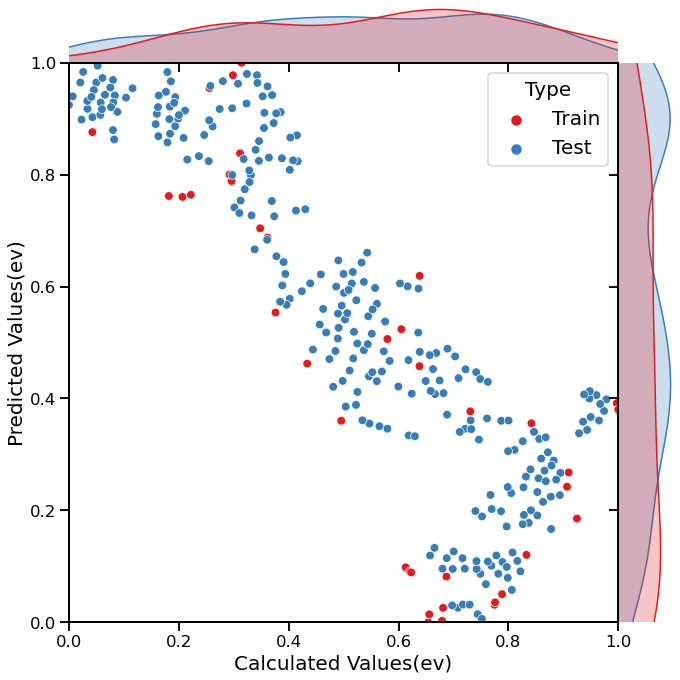

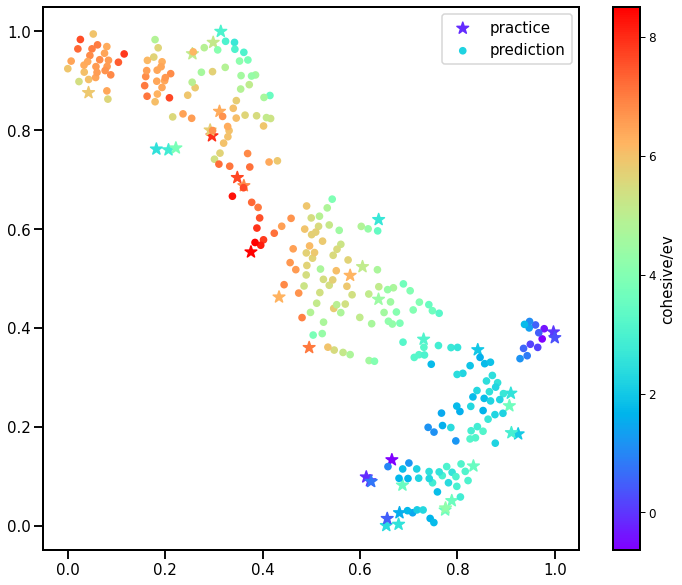

In [53]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn import manifold
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from modules import *
import seaborn as sns

File = '../newdata/NT-CO'

X,y=sub_data(File)
scaler=StandardScaler()
scaler.fit(X)
X=scaler.transform(X)
#X=np.delete(X,[0,1,4,5],axis=1)
# 电阻部分去除异常数据
# X=np.delete(X,[29],axis=0)
# y=np.delete(y,[29],axis=0)
# # #用于除去实验数据
# X=np.delete(X,list(range(43)),axis=0)
# y=np.delete(y,list(range(43)),axis=0)


'''t-SNE'''
tsne = manifold.TSNE(n_components=2,init='pca', random_state=501)
X_tsne = tsne.fit_transform(X)
print("Org data dimension is {}.Embedded data dimension is {}".format(X.shape[-1], X_tsne.shape[-1]))
 
'''visualization'''

x_min, x_max = X_tsne.min(0), X_tsne.max(0)
X_norm = (X_tsne - x_min) / (x_max - x_min)  # 归一化
y_train =[]
y_pre1=[]
y_test=[]
y_pre2=[]
# y_train =X_norm[:43,0]
# y_pre1=X_norm[:43,1]
# y_test=X_norm[44:,0]
# y_pre2=X_norm[44:,1]
# 内聚能
y_train =X_norm[:38,0]
y_pre1=X_norm[:38,1]
y_test=X_norm[39:,0]
y_pre2=X_norm[39:,1]


plot_train_test_results_1(y_train,y_test,y_pre1,y_pre2)

plt.figure(figsize=(12,10))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
#is_first_43_rows = np.arange(X_norm.shape[0]) < 45
#内聚能
is_first_43_rows = np.arange(X_norm.shape[0]) < 40

# 为前43行和剩余行分别绘制散点图
plt.scatter(X_norm[is_first_43_rows, 0], X_norm[is_first_43_rows, 1], 
            c=y[is_first_43_rows], cmap=plt.cm.rainbow, 
            marker='*',s=150, alpha=1, label='practice')  # 使用三角形标记

plt.scatter(X_norm[~is_first_43_rows, 0], X_norm[~is_first_43_rows, 1], 
            c=y[~is_first_43_rows], cmap=plt.cm.rainbow, s=150,alpha=1, 
            marker ='.',label='prediction')  # 使用圆形标记

# 绘制边缘联合分布
#g.plot_marginals(sns.kdeplot,fill=True,palette=patt,common_norm=False) 

#path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y, cmap=plt.cm.rainbow)
# 添加图例
plt.legend(fontsize=15)
cb=plt.colorbar(drawedges=False, orientation='vertical',spacing='uniform')
cb.set_label('cohesive/ev', fontsize=15)
#cb.set_label('ρ0×λ*10E-16/Ωm2', fontsize=15)
#cb.ax.tick_params(length=2)
#cb.ax.tick_params(size=1,width=1,color='b')
cb.ax.tick_params(size=5,width=1,labelsize=12)

plt.savefig('NO-EL.png',dpi=300,bbox_inches='tight')
plt.show()

(100, 6)
Org data dimension is 6.Embedded data dimension is 2


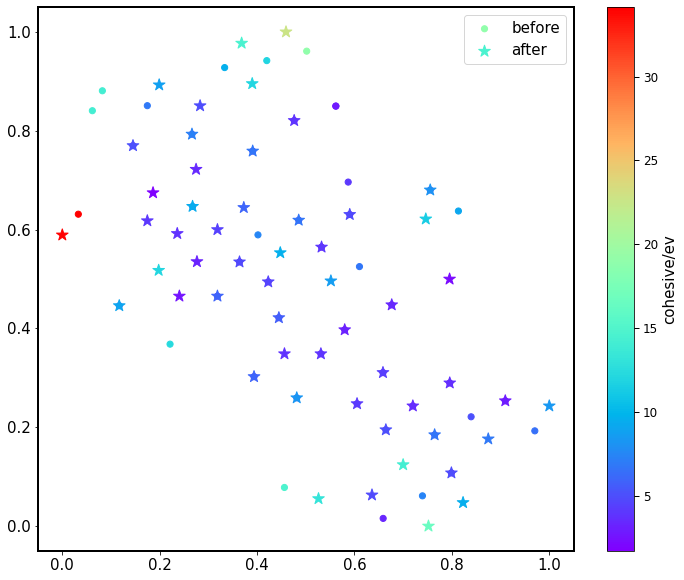

In [1]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn import manifold
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from modules import *
import seaborn as sns

File = '../newdata/fenbuceshi-EL'

X,y=sub_data(File)
scaler=StandardScaler()
scaler.fit(X)
X=scaler.transform(X)
#X=np.delete(X,[0,1,4,5],axis=1)
# 电阻部分去除异常数据
# X=np.delete(X,[29],axis=0)
# y=np.delete(y,[29],axis=0)
# # #用于除去实验数据
# X=np.delete(X,list(range(43)),axis=0)
# y=np.delete(y,list(range(43)),axis=0)
print(X.shape)

'''t-SNE'''
tsne = manifold.TSNE(n_components=2,init='pca', random_state=501)
X_tsne = tsne.fit_transform(X)
print("Org data dimension is {}.Embedded data dimension is {}".format(X.shape[-1], X_tsne.shape[-1]))
 
'''visualization'''

x_min, x_max = X_tsne.min(0), X_tsne.max(0)
X_norm = (X_tsne - x_min) / (x_max - x_min)  # 归一化
# X_norm=np.delete(X_norm,list(range(43)),axis=0)
# y=np.delete(y,list(range(43)),axis=0)
#y=np.delete(y,[0,1,2],axis=1)
#print(X_norm[-6:,:])
#plt.figure()
#print(X_norm)
plt.figure(figsize=(12,10))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
is_first_43_rows = np.arange(X_norm.shape[0]) < 46

# 内聚能部分
#is_first_43_rows = np.arange(X_norm.shape[0]) < 40

# 为前43行和剩余行分别绘制散点图
plt.scatter(X_norm[is_first_43_rows, 0], X_norm[is_first_43_rows, 1], 
            c=y[is_first_43_rows], cmap=plt.cm.rainbow, 
            marker='.',s=150, alpha=1, label='before')  # 使用三角形标记

plt.scatter(X_norm[~is_first_43_rows, 0], X_norm[~is_first_43_rows, 1], 
            c=y[~is_first_43_rows], cmap=plt.cm.rainbow, s=150,alpha=1, 
            marker ='*',label='after')  # 使用圆形标记

#path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y, cmap=plt.cm.rainbow)
# 添加图例
plt.legend(fontsize=15)
cb=plt.colorbar(drawedges=False, orientation='vertical',spacing='uniform')
cb.set_label('cohesive/ev', fontsize=15)
#cb.set_label('ρ0×λ*10E-16/Ωm2', fontsize=15)
#cb.ax.tick_params(length=2)
#cb.ax.tick_params(size=1,width=1,color='b')
cb.ax.tick_params(size=5,width=1,labelsize=12)

plt.savefig('NO-EL.png',dpi=300,bbox_inches='tight')
plt.show()